# Risky Business: Quantitative Portfolio Management for Optimized Risk

## Portfolio Resilience: Backtesting Asset Allocation Strategies During Financial Crises

**Dane Herrin and Alexander Jackson**  
DATA 510 Data Science Capstone  
Willamette University  
Summer 2026

## Title, Team, and Affiliations

**Project Title:** Risky Business: Quantitative Portfolio Management for Optimized Risk  
**Project Subtitle:** Portfolio Resilience: Backtesting Asset Allocation Strategies During Financial Crises  
**Team Members:** Dane Herrin and Alexander Jackson  
**Peer Stakeholder POs:** Ben Dyer, Luca Casano, Manish Reddy Kallu  
**Studio Session:** 4  
**Course:** DATA 510 Data Science Capstone  
**Institution:** Willamette University  
**Term:** Summer 2026  
**Repository:** https://github.com/awjackson00/data510-Quant-Back-Testing

## Abstract

This project evaluates how different portfolio constructions perform during normal market conditions, growth periods, and financial crises. Investors often focus primarily on total return, but return alone does not reveal the amount or type of risk required to achieve that performance. During crises, portfolios that perform well in growth periods can become substantially more volatile and experience significant drawdowns.

We developed a reproducible backtesting workflow using historical daily market data obtained from Yahoo Finance through the `yfinance` Python package (Aroussi, n.d.; Yahoo, n.d.). Five portfolio constructions were evaluated: Barbell, Mega-Cap Technology, Energy, Real Estate, and Fast-Moving Consumer Goods (FMCG). The portfolios were compared across nine market regimes ranging from the Dot-com crash through the post-2023 period and were also evaluated against broad-market benchmarks.

Performance was measured using annualized return, annualized volatility, Sharpe ratio, Sortino ratio, rolling one-year Sharpe ratio, cumulative return, and regime-specific behavior. The quantitative results show substantial differences across regimes. For example, Mega-Cap Technology produced a 63.10% annualized return with a 1.833 Sharpe ratio during the 2020–2021 COVID period, but produced a -46.35% annualized return and -1.179 Sharpe ratio during the 2022 rate cycle. Energy behaved almost oppositely during 2022, producing a 39.60% annualized return and 1.484 Sharpe ratio. FMCG was considerably more stable during the same period, with a -1.13% annualized return.

The results demonstrate that no single portfolio was consistently dominant across every market regime. High-growth portfolios provided substantial upside but also experienced significant downside during stress periods. Defensive portfolios reduced some forms of exposure but came with opportunity costs and were not immune to losses. ARIMA forecasting was also evaluated but did not reveal strong predictive structure in daily portfolio returns. Overall, the project supports using multiple return and downside-risk metrics rather than evaluating portfolio resilience through return alone.

## Introduction: Problem and Research Questions

Many investors and analysts evaluate portfolios based on expected gains, recent performance, or exposure to popular sectors. This can be misleading because financial crises frequently expose risks that are difficult to observe during stable market conditions. A portfolio can perform extremely well during a long expansion and still experience substantial losses when volatility rises, interest rates change, or correlations between assets increase.

This project focuses on risk-aware portfolio backtesting. Instead of asking only which portfolio earned the highest return, we evaluate which portfolios preserved value, limited downside exposure, and maintained stronger risk-adjusted performance across different market environments.

The primary research question is:

> **How can portfolio optimization help stakeholders construct portfolios that preserve return potential while reducing drawdowns during periods of financial crisis and market uncertainty?**

The supporting research questions are:

1. Do drawdown-resistant portfolios experience lower gains during growth years compared with regular market indexes?
2. How does portfolio performance during crisis periods compare with performance during normal market conditions?
3. How are Sharpe and Sortino ratios affected during periods of uncertainty compared with periods of growth?
4. How do technology, energy, real estate, consumer staples, and defensive Treasury-based portfolios behave during different forms of market stress?

These questions move the analysis beyond return maximization. In this project, portfolio resilience refers to the ability to maintain reasonable return potential while limiting volatility, downside risk, and deterioration in risk-adjusted performance during adverse market conditions.

## Impact and Stakeholders

This project is designed for stakeholders who need to evaluate portfolio risk beyond simple total return. Potential stakeholders include institutional funds, risk-averse investors, portfolio managers, financial analysts, finance educators, investment clubs, risk managers, and students studying portfolio analytics.

The practical value of this project is that it demonstrates the tradeoff between upside potential and downside protection. A portfolio with the highest historical return is not necessarily the best portfolio for every stakeholder. Some investors may prioritize maximum long-term growth, while others may place greater value on lower drawdowns, reduced volatility, or more consistent performance across market regimes.

The results make this tradeoff visible. Mega-Cap Technology, for example, achieved extremely strong performance in several growth periods but experienced a -46.35% annualized return during the 2022 rate cycle. Energy experienced the same market environment very differently, generating a 39.60% annualized return during 2022. These differences show why portfolio decisions should consider the type of risk exposure rather than relying solely on historical average returns.

This project is educational and analytical and is not intended to provide investment advice. Its purpose is to demonstrate how historical backtesting can support more informed thinking about diversification, downside risk, asset allocation, and portfolio resilience.

## Related Work and Background

This project builds on concepts from modern portfolio theory, risk-adjusted return analysis, financial backtesting, crisis-period analysis, and time-series modeling.

Modern portfolio theory formalized the idea that investors should evaluate portfolios jointly in terms of expected return and variance rather than assessing securities in isolation (Markowitz, 1952). Diversification can reduce portfolio risk when assets have different return patterns, although crisis periods may weaken those diversification benefits when correlations change.

Risk-adjusted metrics provide additional information beyond total return. The Sharpe framework evaluates return relative to total volatility and is grounded in the broader development of equilibrium asset pricing and risk-return tradeoffs (Sharpe, 1964). In this project, higher Sharpe ratios indicate stronger excess return per unit of total return volatility.

The Sortino ratio instead emphasizes downside deviation, distinguishing harmful downside variation from upside variation (Sortino & van der Meer, 1991; Sortino & Price, 1994). This is particularly relevant because the central research question concerns drawdowns and portfolio behavior under adverse conditions.

The project also considers fragility and asymmetric responses to stress. Taleb (2012) argues that systems should be evaluated not only by average outcomes but also by how they respond to volatility, disorder, and extreme events. That perspective motivates the project's emphasis on regime-specific portfolio behavior rather than relying only on full-period averages.

ARIMA was evaluated as a statistical time-series baseline using the Box–Jenkins framework (Box et al., 2015). The implementation used `statsmodels`, a Python package for econometric and statistical modeling (Seabold & Perktold, 2010). ARIMA was not interpreted as a trading strategy; instead, it was used to test whether portfolio-level daily returns exhibited sufficiently stable autoregressive structure to support short-horizon forecasting.

The broader empirical workflow was also informed by the reproducible-finance approach described by Voigt et al. (2024), which emphasizes transparent, reproducible financial analysis in Python.

## Data and Data Engineering

Historical daily market prices were collected from Yahoo Finance through `yfinance` (Aroussi, n.d.; Yahoo, n.d.). The project developed daily return series for the individual assets, constructed weighted portfolio returns, assigned observations to market regimes, and calculated portfolio-level performance metrics.

### Barbell Portfolio

The final Barbell implementation uses:

- **95% IEF**, representing intermediate-term U.S. Treasury exposure
- **5% ^VIX**, representing volatility exposure

The weights remain fixed at 95% and 5%.

The VIX component is an analytical proxy rather than an investable security. Earlier exploratory notebooks tested alternative Treasury proxies, but the final Sharpe, Sortino, and regime-level metrics reported in this paper use IEF and VIX.

### Mega-Cap Technology Portfolio

The Mega-Cap Technology portfolio consists of Apple, Microsoft, NVIDIA, Amazon, Google, Meta, Broadcom, and Tesla. When all eight securities are available, each receives a target weight of **12.5%**.

Because several companies did not have publicly traded data during the earliest regimes, the final analysis dynamically equal-weights the securities available on each date. This prevents unavailable pre-IPO securities from being treated as if they existed historically.

### Energy Portfolio

The Energy portfolio contains ExxonMobil, Chevron, ConocoPhillips, EOG Resources, Schlumberger, NextEra Energy, Duke Energy, Constellation Energy, Southern Company, and Dominion Energy.

With all ten holdings available, each receives a target weight of **10%**. The analysis dynamically equal-weights the securities that are available on each date.

### Real Estate Portfolio

The Real Estate portfolio is **100% Vanguard Real Estate ETF (VNQ)**. Because VNQ did not begin trading until 2004, the portfolio does not have results for the Dot-com crash regime.

### Fast-Moving Consumer Goods Portfolio

The FMCG portfolio consists of Walmart, Costco, Target, Procter & Gamble, Unilever, Kimberly-Clark, Coca-Cola, PepsiCo, Nestlé, and General Mills. Each company receives an equal **10% target weight**.

### Benchmarks

The analysis also uses broad-market benchmark series to provide context for portfolio performance, including the S&P 500 and market return minus the risk-free rate where applicable.

The primary processing pipeline is:

**Ticker and portfolio definitions → historical prices → daily returns → portfolio weighting → portfolio returns → regime labels → performance metrics → visualizations**

The final reported regime metrics use the analysis window from January 1, 2000 through May 1, 2025.

## Ethics and Responsible Use

All data used in this project are public financial-market data. The project does not contain personally identifiable information, private investor information, account-level data, or restricted financial records.

The first major ethical risk is that readers could interpret the analysis as investment advice. The project therefore presents all findings as historical and educational. Historical portfolio performance does not demonstrate that the same strategy will perform similarly in future markets.

The second major risk is **backtesting overconfidence**. Portfolio strategies are being evaluated after the relevant market events have already occurred. Researchers therefore know which companies survived, which sectors performed well, and what each crisis ultimately looked like. This introduces hindsight that would not have been available to an investor making decisions in real time.

A related issue is **survivorship bias**. The portfolios contain securities that are currently known and available. Companies that failed, disappeared, or were acquired may be underrepresented. Historical results may therefore make the construction of some portfolios appear cleaner than it would have been prospectively.

Different asset inception dates also create comparability issues. The analysis partially addresses this for multi-stock portfolios through dynamic equal weighting across available securities, but the composition of those portfolios consequently changes over time.

Finally, the VIX is not directly investable. The Barbell portfolio therefore represents a theoretical volatility-sensitive construction rather than a directly implementable investment strategy. A practical portfolio would require an investable volatility instrument, derivatives strategy, or other tail-risk implementation.

## Methods and Evaluation

Portfolio returns are calculated from daily security returns using the portfolio construction rules described above. Performance is then evaluated separately across defined historical market regimes.

### Market Regime Definitions

| Regime | Date Range |
|---|---|
| Dot-com crash | January 1, 2000 – October 9, 2002 |
| Recovery | October 10, 2002 – December 31, 2007 |
| Global Financial Crisis (GFC) | January 1, 2008 – December 31, 2009 |
| Recovery / ZIRP | January 1, 2010 – December 31, 2015 |
| Pre-COVID | January 1, 2016 – December 31, 2019 |
| COVID | January 1, 2020 – December 31, 2021 |
| 2022 Rate Cycle | January 1, 2022 – December 31, 2022 |
| Regional Banking Stress | March 1, 2023 – May 31, 2023 |
| Post-Crisis | June 1, 2023 – May 1, 2025 |

The Dot-com results require additional caution. IEF began trading during 2002, meaning the Barbell portfolio does not cover the full Dot-com window even though enough observations exist to calculate metrics. VNQ did not yet exist and therefore has no Dot-com result.

### Evaluation Metrics

Each portfolio is evaluated using:

- Annualized return
- Annualized volatility
- Sharpe ratio
- Sortino ratio
- Cumulative return
- Rolling one-year Sharpe ratio
- Crisis-period performance
- Recovery-period performance
- Benchmark comparison

Annualized return in the summary analysis is calculated by multiplying mean daily return by 252 trading days. Sharpe ratios use daily excess returns relative to the risk-free rate and are annualized using the square root of 252. The Sharpe ratio is used as a total-volatility risk-adjusted measure (Sharpe, 1964). Sortino ratios similarly use excess returns but focus on downside deviation (Sortino & Price, 1994).

Cumulative-return figures provide an additional interpretation because annualized arithmetic return can be sensitive to the length of the evaluation period. This is especially important for short regimes such as the three-month regional banking period.

### ARIMA

ARIMA was evaluated on portfolio-level daily return series using the Box–Jenkins time-series framework (Box et al., 2015) and the `statsmodels` implementation (Seabold & Perktold, 2010).

The purpose was not to create a trading strategy but to test whether daily portfolio returns contained stable autoregressive structure. The models generally produced forecasts close to zero and did not yield strong or consistent predictive results. Because of this, ARIMA is treated as an inconclusive statistical result rather than a primary source of portfolio recommendations.

## Results and Visualizations

The results show that portfolio behavior varies substantially across market regimes. The summary metrics below provide the quantitative evidence behind the regime-level comparisons instead of requiring the figures to carry the entire evidentiary burden.

### Table 1. Summary Performance Metrics by Portfolio and Market Regime

| Regime | Portfolio | Sharpe | Sortino | Annualized Return |
|---|---|---:|---:|---:|
| Dot-com crash | Barbell* | 3.720 | 6.908 | 45.70% |
| Dot-com crash | Mega Tech | -0.163 | -0.284 | -5.72% |
| Dot-com crash | Energy | 0.272 | 0.414 | 10.10% |
| Dot-com crash | REIT (VNQ) | N/A | N/A | N/A |
| Dot-com crash | FMCG | 0.066 | 0.105 | 5.18% |
| Recovery | Barbell | 0.406 | 0.664 | 6.11% |
| Recovery | Mega Tech | 1.731 | 2.662 | 50.31% |
| Recovery | Energy | 1.448 | 2.183 | 26.79% |
| Recovery | REIT (VNQ) | 0.499 | 0.705 | 13.73% |
| Recovery | FMCG | 0.868 | 1.348 | 12.80% |
| GFC | Barbell | 0.577 | 1.057 | 7.88% |
| GFC | Mega Tech | 0.202 | 0.299 | 9.37% |
| GFC | Energy | 0.006 | 0.008 | 0.95% |
| GFC | REIT (VNQ) | 0.187 | 0.279 | 13.58% |
| GFC | FMCG | 0.190 | 0.259 | 5.25% |
| Recovery / ZIRP | Barbell | 0.817 | 1.504 | 8.58% |
| Recovery / ZIRP | Mega Tech | 1.289 | 1.901 | 28.74% |
| Recovery / ZIRP | Energy | 0.665 | 0.958 | 10.85% |
| Recovery / ZIRP | REIT (VNQ) | 0.772 | 1.026 | 15.47% |
| Recovery / ZIRP | FMCG | 1.060 | 1.515 | 12.17% |
| Pre-COVID | Barbell | 0.601 | 1.167 | 7.00% |
| Pre-COVID | Mega Tech | 1.308 | 1.671 | 29.88% |
| Pre-COVID | Energy | 0.684 | 1.014 | 10.63% |
| Pre-COVID | REIT (VNQ) | 0.552 | 0.755 | 9.05% |
| Pre-COVID | FMCG | 1.079 | 1.471 | 13.53% |
| COVID | Barbell | 0.802 | 1.552 | 8.90% |
| COVID | Mega Tech | 1.833 | 2.162 | 63.10% |
| COVID | Energy | 0.458 | 0.563 | 16.62% |
| COVID | REIT (VNQ) | 0.620 | 0.663 | 19.68% |
| COVID | FMCG | 0.916 | 1.133 | 18.41% |
| 2022 Rate Cycle | Barbell | -1.259 | -2.368 | -11.15% |
| 2022 Rate Cycle | Mega Tech | -1.179 | -1.973 | -46.35% |
| 2022 Rate Cycle | Energy | 1.484 | 2.230 | 39.60% |
| 2022 Rate Cycle | REIT (VNQ) | -1.194 | -1.884 | -27.51% |
| 2022 Rate Cycle | FMCG | -0.168 | -0.209 | -1.13% |
| Regional Banking Stress | Barbell | 0.482 | 0.930 | 11.43% |
| Regional Banking Stress | Mega Tech | 4.397 | 11.928 | 117.08% |
| Regional Banking Stress | Energy | -0.630 | -0.897 | -6.72% |
| Regional Banking Stress | REIT (VNQ) | -1.211 | -1.720 | -21.00% |
| Regional Banking Stress | FMCG | 0.381 | 0.563 | 8.88% |
| Post-Crisis | Barbell | 0.287 | 0.507 | 7.72% |
| Post-Crisis | Mega Tech | 1.045 | 1.497 | 35.48% |
| Post-Crisis | Energy | 0.490 | 0.661 | 13.56% |
| Post-Crisis | REIT (VNQ) | 0.341 | 0.503 | 11.22% |
| Post-Crisis | FMCG | 0.365 | 0.552 | 9.34% |

*The Barbell Dot-com result uses only the portion of the regime for which IEF data are available and therefore should not be interpreted as performance across the full 2000–2002 crash.*

**Source:** Authors' calculations from the final portfolio return series in `SharpeRatioSheet.ipynb`.

Table 1 demonstrates why the type of crisis is critical to portfolio evaluation. There is no portfolio that consistently ranks first across all regimes.

Mega-Cap Technology generated some of the highest returns in the analysis. It produced a **50.31% annualized return with a 1.731 Sharpe ratio during the 2002–2007 recovery**, a **29.88% annualized return with a 1.308 Sharpe ratio during the Pre-COVID period**, and a **63.10% annualized return with a 1.833 Sharpe ratio during 2020–2021**. These results demonstrate substantial upside during expansionary and recovery environments.

However, the same portfolio was one of the weakest during the 2022 rate cycle. Its annualized return declined to **-46.35%**, while its Sharpe ratio fell to **-1.179** and Sortino ratio to **-1.973**. This is direct evidence of the downside tradeoff associated with concentrated growth exposure.

Energy produced a different pattern. During the Global Financial Crisis its annualized return was only **0.95%** with a Sharpe ratio near zero at **0.006**, but during the 2022 rate cycle it was the strongest portfolio in the comparison, producing a **39.60% annualized return**, **1.484 Sharpe ratio**, and **2.230 Sortino ratio**.

FMCG generally displayed more moderate results. During the 2022 rate cycle, FMCG returned **-1.13%**, substantially better than Mega Tech at -46.35% and VNQ at -27.51%. Its Sharpe ratio of **-0.168** was still negative, but the magnitude of deterioration was significantly smaller than in the growth and real-estate portfolios.

The results also reinforce the limits of labeling a single portfolio as universally defensive. The Barbell portfolio generated positive risk-adjusted results across several periods, including a **0.817 Sharpe ratio and 1.504 Sortino ratio during Recovery/ZIRP**, but it also experienced a **-11.15% annualized return and -1.259 Sharpe ratio during the 2022 rate cycle**.

### Figure 1. Rolling One-Year Sharpe Ratio by Portfolio

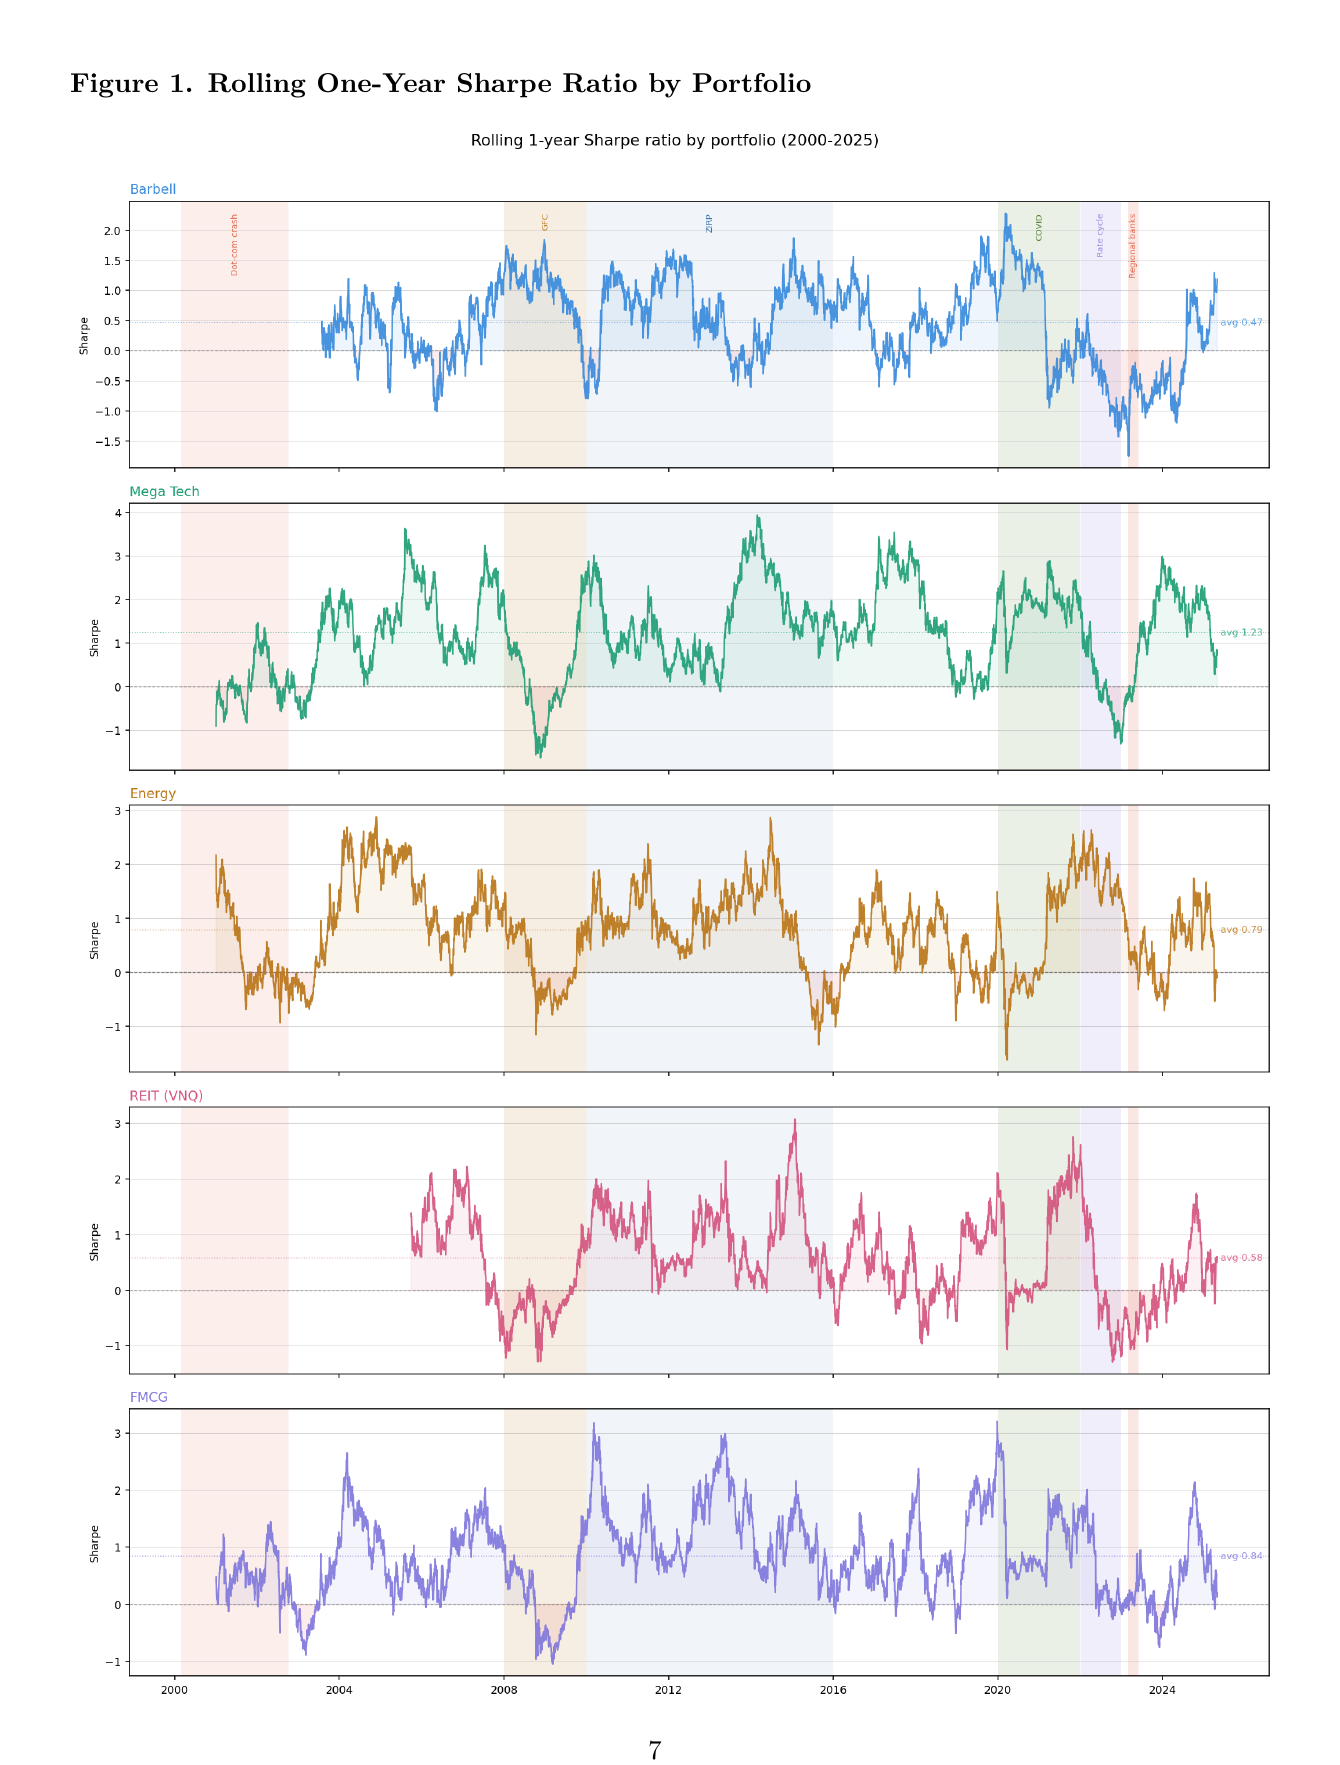

Figure 1 shows the rolling one-year Sharpe ratios for Barbell, Mega-Cap Technology, Energy, Real Estate, and FMCG. The shaded regions identify major stress and recovery regimes.

The figure reinforces the regime-level metrics in Table 1. Mega-Cap Technology frequently achieved strong positive rolling Sharpe ratios during growth periods but experienced sharp deterioration during stressful markets. The primary takeaway is that risk-adjusted performance is not stable through time. Even portfolios with strong long-term performance can experience periods in which their risk-adjusted returns become negative.

**Source:** Authors' calculations.

### Figure 2. Benchmark Cumulative Returns by Regime

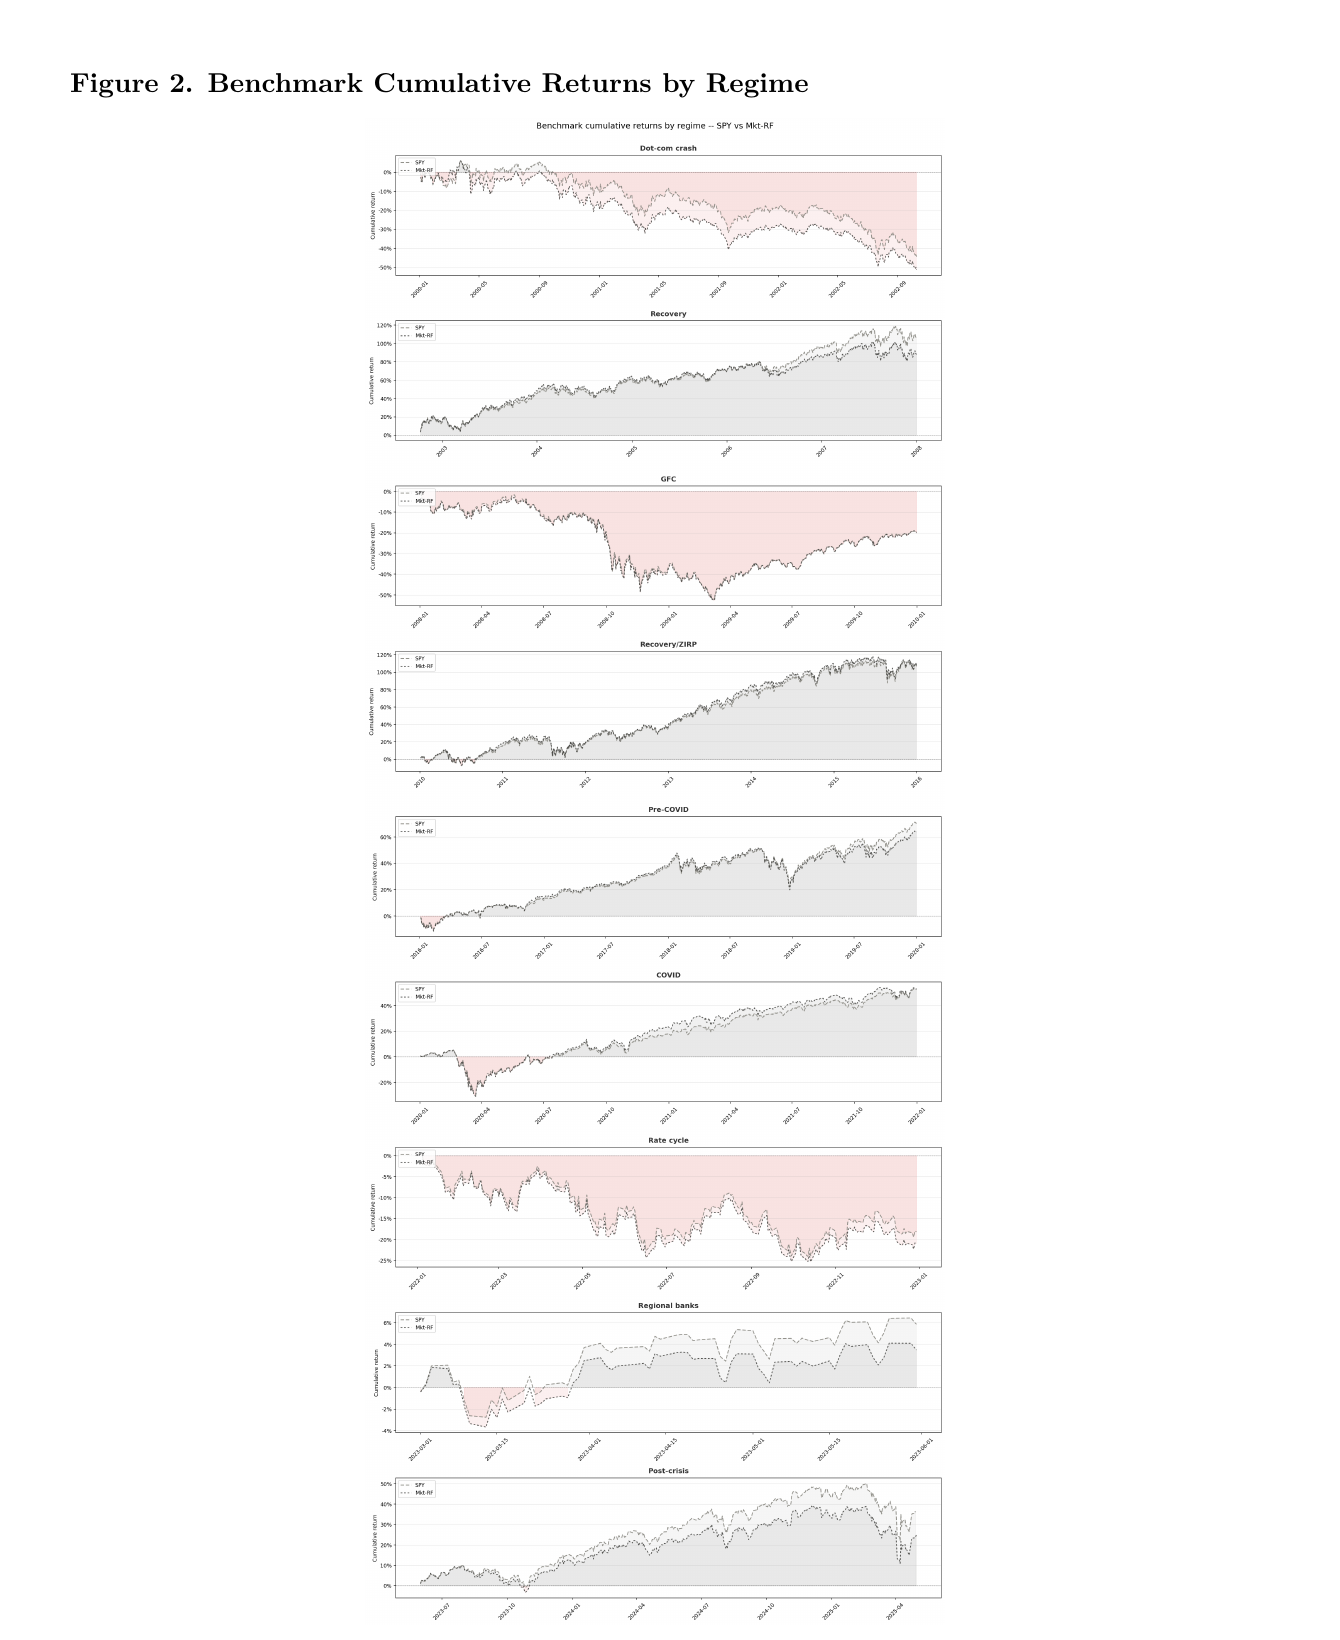

Figure 2 compares SPY and Mkt-RF across the defined market regimes. The benchmark series experienced substantial weakness during the Dot-com crash, Global Financial Crisis, and 2022 rate cycle. The COVID period shows a sharp initial decline followed by substantial recovery, while the regional banking stress period was shorter and less severe for the broad benchmark series.

This figure provides context for interpreting the constructed portfolios. Broad-market exposure itself behaves differently depending on the market environment, so positive portfolio performance during a recovery does not necessarily demonstrate superior portfolio construction. Comparing the portfolios with benchmarks helps distinguish portfolio-specific resilience from general market recovery.

**Source:** Authors' calculations.

### Figure 3. Cumulative Returns by Regime for Portfolios and Benchmarks

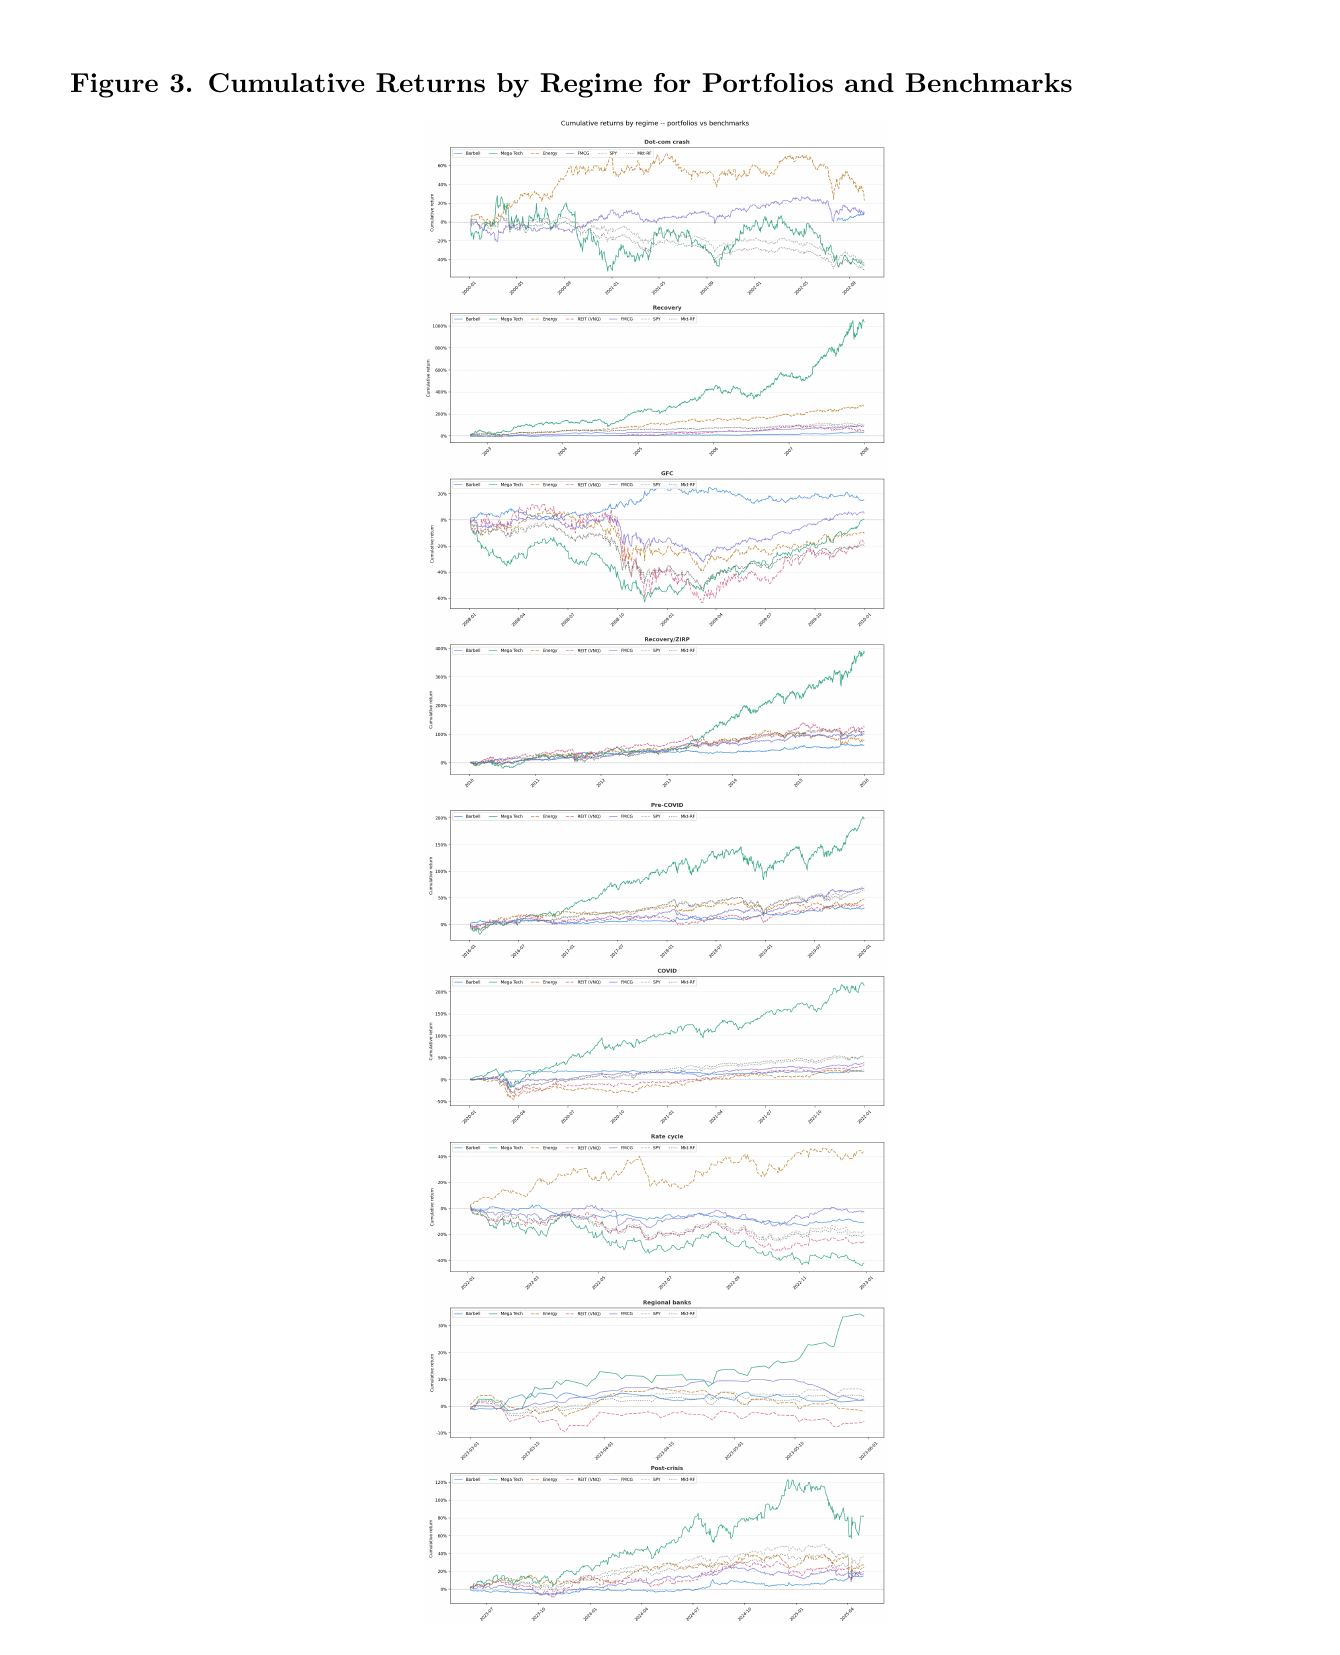

Figure 3 compares all five constructed portfolios with the benchmark series within each regime.

Mega-Cap Technology produced the strongest cumulative upside during several recovery and expansion periods, consistent with its 50.31% annualized return during the 2002–2007 recovery, 29.88% during Pre-COVID, and 63.10% during the COVID regime. However, its 2022 performance illustrates the cost of this upside exposure.

Energy behaved differently depending on the nature of the crisis. Its strong 39.60% annualized return during the 2022 rate cycle contrasts with its near-flat 0.95% annualized return during the GFC and -6.72% annualized result during regional banking stress.

The Barbell portfolio generally produced more moderate outcomes and did not dominate cumulative returns. Its role is therefore better interpreted as a defensive comparison than a return-maximizing portfolio.

FMCG also displayed relatively moderate behavior. It did not capture the same upside as Mega-Cap Technology during major growth periods, but its -1.13% annualized return during 2022 illustrates how its downside behavior differed from the much larger losses in Mega Tech and Real Estate.

Together, Table 1 and Figures 1–3 show that portfolio resilience depends on both the portfolio and the specific market regime.

**Source:** Authors' calculations.

### ARIMA Results

ARIMA was evaluated as a time-series forecasting method using the Box–Jenkins framework (Box et al., 2015) and `statsmodels` (Seabold & Perktold, 2010), but it did not produce sufficiently strong results to justify using it as a primary visualization or decision model.

Daily portfolio returns are noisy and frequently centered near zero. The ARIMA forecasts similarly tended to converge toward near-zero values and did not reveal stable predictive structure across portfolios.

This should not be interpreted as a mechanical failure of ARIMA. Instead, it represents a useful null result: under the specifications tested in this project, simple ARIMA models did not provide enough predictive information to improve the central portfolio-resilience analysis.

The project's strongest evidence therefore comes from historical backtesting, risk-adjusted performance metrics, benchmark comparisons, and regime-specific return behavior.

## Discussion, Limitations, and Future Work

The results demonstrate that portfolio resilience cannot be represented by a single number. Return, volatility, Sharpe ratio, Sortino ratio, drawdowns, and regime-specific performance all provide different information.

Mega-Cap Technology demonstrates the clearest risk-return tradeoff. It was the strongest portfolio across several expansion periods, including a 63.10% annualized return during the COVID regime, but it also produced the largest loss among the five portfolios during the 2022 rate cycle at -46.35%.

Energy demonstrates that sector performance is highly dependent on the type of crisis. It provided little risk-adjusted return during the GFC but strongly outperformed the other portfolios during 2022.

FMCG demonstrated comparatively stable behavior in several stress periods but did not participate in growth to the same extent as Mega-Cap Technology. The Barbell construction similarly provided a useful defensive comparison but did not eliminate downside exposure.

Real Estate was particularly sensitive to changing financial conditions. VNQ had a -27.51% annualized return and -1.194 Sharpe ratio during the 2022 rate cycle and a -21.00% annualized return during regional banking stress.

Several limitations affect interpretation.

First, historical performance does not guarantee future performance. The analysis evaluates known historical crises, while future crises may arise from different causes.

Second, backtesting creates a risk of hindsight bias and overconfidence. Portfolio composition is being evaluated after the outcomes of these crises are known.

Third, survivorship bias may affect the selected holdings. The portfolios consist largely of companies and assets that are recognizable and available today.

Fourth, asset inception dates differ. Dynamic equal weighting reduces this problem for the stock portfolios, but portfolio composition is not perfectly constant through time. VNQ does not exist during the Dot-com regime, and IEF provides only partial coverage near the end of the Dot-com crash.

Fifth, the VIX is not directly investable. The Barbell portfolio should therefore be interpreted as a theoretical volatility-sensitive comparison rather than an immediately implementable trading portfolio.

Sixth, the regional banking regime covers only three months. Annualizing returns from a short interval can create very large values. The Mega Tech annualized return of 117.08% during that regime should therefore be interpreted together with the cumulative-return figure rather than as an expectation of a sustainable annual return.

Seventh, transaction costs, taxes, bid-ask spreads, and portfolio rebalancing costs are not included.

Eighth, Yahoo Finance data and adjusted prices may be revised. Reproducibility therefore depends on documenting the analysis window and code used to create the final outputs (Aroussi, n.d.; Yahoo, n.d.).

Ninth, ARIMA forecasting was inconclusive and did not reveal stable predictive structure in daily portfolio returns.

Future work could extend the project by calculating formal maximum drawdown statistics for every portfolio and regime, testing alternative crisis definitions, incorporating transaction costs, comparing multiple rebalancing schedules, replacing VIX with an investable volatility strategy, and performing optimization that selects portfolio weights prospectively rather than evaluating only predefined portfolios.

## Conclusions and Recommendations

This project shows that portfolio resilience should not be judged using return alone.

The results provide clear examples. Mega-Cap Technology generated a 63.10% annualized return during the COVID regime but lost 46.35% on an annualized basis during the 2022 rate cycle. Energy generated 39.60% during that same 2022 environment, while FMCG declined only 1.13%. The same market event therefore affected different portfolio constructions in dramatically different ways.

No single portfolio was consistently best across all nine regimes. Growth-oriented portfolios provided substantial upside but were vulnerable to certain stress environments. Defensive portfolios reduced exposure to some market risks but also experienced losses and sacrificed return during long growth periods.

Stakeholders should therefore evaluate portfolios using a multi-metric framework. Cumulative return measures upside potential. Annualized volatility measures instability. Sharpe ratio measures return relative to total risk (Sharpe, 1964). Sortino ratio focuses specifically on downside risk (Sortino & Price, 1994). Regime-specific analysis shows whether these relationships remain stable when market conditions change.

The strongest practical recommendation is not to select a portfolio based only on the strategy with the highest historical cumulative return. Stakeholders should instead identify the risk exposures they are willing to tolerate and evaluate whether the portfolio continues to behave acceptably during adverse regimes.

ARIMA and similar forecasting methods should be treated as supporting analytical tools rather than primary decision engines. In this analysis, ARIMA did not provide conclusive predictive value.

Overall, the project provides a reproducible framework for comparing return potential with downside resilience across historical market conditions. Its purpose is educational rather than advisory, but the results demonstrate why risk-aware, regime-specific portfolio evaluation is important.

## Reproducibility

The project repository is available at:

**https://github.com/awjackson00/data510-Quant-Back-Testing**

The primary analysis notebooks are:

- `notebooks/EDA Capstone.ipynb`
- `notebooks/SharpeRatioSheet.ipynb`
- `notebooks/portfolioConstruction.ipynb`
- `notebooks/ARIMA Time-Series Modeling.ipynb`

The final regime-level Sharpe, Sortino, return, and volatility calculations reported in this paper are generated in `SharpeRatioSheet.ipynb`.

The primary dependencies include Python, NumPy, pandas, `yfinance`, Tidy Finance, matplotlib, seaborn, `statsmodels`, and scikit-learn. `yfinance` provides programmatic access to Yahoo Finance market data for research and educational use (Aroussi, n.d.), while Tidy Finance provides a reproducible framework for empirical financial research in Python (Voigt et al., 2024).

To reproduce the analysis, a reader should clone the repository, install the listed dependencies, rebuild the historical price and daily-return data, construct the portfolio return series using the documented weighting rules, assign observations to the specified regime date ranges, and then run the Sharpe/Sortino and visualization notebooks.

Reproducibility depends especially on preserving the exact portfolio definitions, historical regime dates, and data-analysis window. Yahoo Finance may revise historical adjusted prices or ticker availability, so future data pulls may differ slightly from the data used to generate the final results.

## References

Aroussi, R. (n.d.). *yfinance* [Computer software]. GitHub. https://github.com/ranaroussi/yfinance

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5th ed.). John Wiley & Sons.

Markowitz, H. (1952). Portfolio selection. *The Journal of Finance, 7*(1), 77–91. https://doi.org/10.2307/2975974

Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96).

Sharpe, W. F. (1964). Capital asset prices: A theory of market equilibrium under conditions of risk. *The Journal of Finance, 19*(3), 425–442. https://doi.org/10.1111/j.1540-6261.1964.tb02865.x

Sortino, F. A., & Price, L. N. (1994). Performance measurement in a downside risk framework. *The Journal of Investing, 3*(3), 59–64. https://doi.org/10.3905/joi.3.3.59

Sortino, F. A., & van der Meer, R. (1991). Downside risk: Capturing what's at stake in investment situations. *The Journal of Portfolio Management, 17*(4), 27–31. https://doi.org/10.3905/jpm.1991.409343

Taleb, N. N. (2012). *Antifragile: Things that gain from disorder*. Random House.

Voigt, S., Scheuch, C., Weiss, P., & Frey, C. (2024). *Tidy Finance with Python*. Taylor & Francis. https://doi.org/10.1201/9781032684307

Yahoo. (n.d.). *Yahoo Finance: Historical data*. Retrieved August 14, 2026, from https://finance.yahoo.com/